# Изучение рынка заведений общественного питания Москвы

- Автор: Екатерина Мирау
- Дата: 15.03.2026

### Цели и задачи проекта<br>

<font color='#000000'>

**Цель проекта** — провести исследовательский анализ рынка заведений общественного питания Москвы на основе данных сервиса Яндекс Карты и Яндекс Бизнес, чтобы выявить структуру рынка, особенности распределения заведений по категориям и районам, а также определить факторы, которые могут повлиять на выбор формата и расположения нового заведения.

Для достижения цели необходимо решить следующие задачи:

* загрузить и изучить предоставленные данные;

* объединить датасеты и подготовить данные к анализу;

* провести предобработку данных (проверить типы данных, обработать пропуски и дубликаты);

* выполнить исследовательский анализ данных;

* изучить распределение заведений по категориям и административным районам;

* исследовать соотношение сетевых и несетевых заведений;

* проанализировать количество посадочных мест, рейтинги и ценовые категории;

* выявить возможные зависимости между характеристиками заведений;

* сформулировать выводы и рекомендации для инвесторов.</font>

### Описание данных

<font color='#000000'>В исследовании используются два датасета, содержащие информацию о заведениях общественного питания Москвы.

Датасет `/datasets/rest_info.csv` содержит информацию о заведениях:

- `name` — название заведения

- `address` — адрес заведения

- `district` — административный район Москвы

- `category` — категория заведения (кафе, ресторан, кофейня и др.)

- `hours` — информация о днях и часах работы

- `rating` — рейтинг заведения по данным Яндекс Карт (максимум 5.0)

- `chain` — признак сетевого заведения
    
    0 — несетевое заведение
    
    1 — сетевое заведение


- `seats` — количество посадочных мест


Датасет `/datasets/rest_price.csv` содержит информацию о ценах:

- `price` — ценовая категория заведения

- `avg_bill` — текстовое описание среднего чека

- `middle_avg_bill` — числовая оценка среднего чека (если указано значение "Средний счёт")

- `middle_coffee_cup` — числовая оценка стоимости чашки капучино (если указано значение "Цена чашки капучино")

Данные были собраны из сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года и носят справочный характер.</font>

### Содержимое проекта

<font color='#000000'>Исследование будет выполнено в несколько этапов:

**1. Загрузка данных и знакомство с ними**  

- загрузка датасетов;

- изучение структуры данных;

- проверка типов данных и наличия пропусков;

- объединение датасетов.

**2. Предобработка данных**

- корректировка типов данных;

- анализ и обработка пропущенных значений;

- поиск и удаление дубликатов;

- создание нового признака круглосуточной работы заведения.

**3. Исследовательский анализ данных**

- анализ категорий заведений;

- исследование распределения заведений по районам Москвы;

- анализ сетевых и несетевых заведений;

- исследование количества посадочных мест;

- анализ рейтингов заведений;

- анализ корреляций между показателями;

- исследование популярных сетей;

- анализ среднего чека и ценовых различий по районам.

**4. Формирование итоговых выводов**

- обобщение результатов исследования;

- выявление ключевых особенностей рынка;

- формирование рекомендаций.</font>

---

## Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные info_df и price_df
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомьтесь с данными и изучите общую информацию о них.

In [4]:
# Выводим первые строки датафрейма на экран
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
# Выводим первые строки датафрейма на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод


На этапе первичного анализа были загружены два датасета: **rest_info.csv** и **rest_price.csv**, содержащие информацию о заведениях общественного питания Москвы и их ценовой категории.

Объём данных составляет:

rest_info.csv — **8406 строк и 9 столбцов**;

rest_price.csv — **4058 строк и 5 столбцов**.

Столбцы в таблицах соответствуют описанию данных.

В датасетах присутствуют **пропущенные значения**.
В таблице rest_info.csv пропуски наблюдаются в столбцах hours и seats, причём особенно много пропусков в количестве посадочных мест. Это может быть связано с тем, что не для всех заведений указано число мест.

В таблице rest_price пропуски встречаются в столбцах price, avg_bill, middle_avg_bill и middle_coffee_cup. Их наличие объясняется структурой данных: числовые показатели заполняются только для определённых типов значений в поле avg_bill.

Типы данных в целом соответствуют содержанию столбцов: текстовые признаки имеют тип object, числовые — float64 и int64, поэтому на данном этапе корректировка типов не требуется.

Также стоит учитывать, что данные представлены в двух отдельных таблицах, поэтому перед дальнейшим анализом их необходимо объединить в один датафрейм. Кроме того, при предобработке следует дополнительно проверить данные на дубликаты и корректность текстовых значений.

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [8]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, how='left', on='id')

In [9]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Данные из двух датасетов были объединены в один датафрейм с помощью метода `merge()` по общему столбцу `id`.  
Для объединения использовался тип соединения `left`, чтобы сохранить все записи из таблицы с информацией о заведениях.

Полученный датафрейм будет использоваться для дальнейшей предобработки и исследовательского анализа данных.

## Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

После объединения датасетов был получен датафрейм df, содержащий **8406 строк** и **13 столбцов**.

Типы данных в целом соответствуют содержанию столбцов:

***name, category, address, district, hours, price, avg_bill*** имеют тип object;

***rating, seats, middle_avg_bill, middle_coffee_cup*** имеют тип float64;

***chain*** имеет тип int64.

Некоторые столбцы содержат пропущенные значения: ***hours, seats, price, avg_bill, middle_avg_bill, middle_coffee_cup***

На данном этапе типы данных выглядят корректными и не требуют изменения. Далее необходимо подробнее изучить пропуски и проверить данные на наличие дубликатов.

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [10]:
# считаем пропуски в каждом столбце
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [11]:
# считаем долю пропусков
(df.isna().mean() * 100).round(2)

id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64

Пропуски в столбце hours могут быть связаны с отсутствием информации о режиме работы заведения в источнике данных. Доля пропусков в этом столбце составляет 6.38%.

Большое количество пропусков в столбце seats вероятно связано с тем, что для некоторых типов заведений (например, небольших кофе-точек или заведений формата takeaway) количество посадочных мест не указывается. Доля пропусков здесь составляет 42.96%.

Пропуски в столбцах price, avg_bill, middle_avg_bill и middle_coffee_cup объясняются структурой данных. Числовые значения среднего чека и стоимости кофе заполняются только в тех случаях, когда соответствующая информация присутствует в текстовом поле avg_bill. Доли пропусков составляют: price — 60.56%, avg_bill — 54.60%, middle_avg_bill — 62.54%, middle_coffee_cup — 93.64%.

Удаление строк с пропусками привело бы к значительной потере данных, поэтому на данном этапе пропущенные значения оставлены без изменений и будут учитываться при дальнейшем анализе.

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [12]:
# проверяем явные дубликаты
df.duplicated().sum()

0

In [13]:
# нормализуем названия заведений
df['name'] = df['name'].str.lower().str.strip()

In [14]:
# убираем лишние пробелы
df['name'] = df['name'].str.replace('  ', ' ')

In [15]:
# ищем дубликаты по названию и адресу
df.duplicated(subset=['name','address']).sum()

3

In [16]:
df[df.duplicated(subset=['name','address'], keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"Москва, проспект Мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","Москва, проспект Мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"Москва, Ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"Москва, Ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


Данные были проверены на наличие **явных и неявных дубликатов**.

Сначала была проведена проверка полных дубликатов строк. **Явные дубликаты** в датафрейме **не обнаружены**.

Для поиска неявных дубликатов была выполнена нормализация текстовых данных: названия заведений приведены к нижнему регистру и очищены от лишних пробелов.

После этого была выполнена проверка дубликатов по сочетанию столбцов name и address. В результате было обнаружено **3 случая возможных дубликатов**. Вероятно, они связаны с тем, что одно и то же заведение может иметь разные категории или режим работы.

Поскольку такие записи могут отражать реальные различия в характеристиках заведений, данные дубликаты **было решено не удалять**.

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [17]:
# смотрим уникальные значения столбца hours
df['hours'].value_counts().head(10)

ежедневно, 10:00–22:00      759
ежедневно, круглосуточно    730
ежедневно, 11:00–23:00      396
ежедневно, 10:00–23:00      310
ежедневно, 12:00–00:00      254
ежедневно, 09:00–21:00      204
ежедневно, 09:00–22:00      184
ежедневно, 12:00–23:00      178
ежедневно, 08:00–23:00      160
ежедневно, 08:00–22:00      148
Name: hours, dtype: int64

In [18]:
# создаем признак круглосуточной работы
df['is_24_7'] = df['hours'].str.contains('ежедневно, круглосуточно', na=False)

# проверяем результат
df[['hours', 'is_24_7']].head(15)

,hours,is_24_7
0,"ежедневно, 10:00–22:00",False
1,"ежедневно, 10:00–22:00",False
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,"ежедневно, 09:00–22:00",False
4,"ежедневно, 10:00–22:00",False
5,"ежедневно, 10:00–23:00",False
6,пн 15:00–04:00; вт-вс 15:00–05:00,False
7,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",False
8,"ежедневно, 10:00–22:00",False
9,"ежедневно, 12:00–00:00",False


Для дальнейшего анализа был создан новый столбец **is_24_7**, который показывает, работает ли заведение **ежедневно и круглосуточно**.

Значение True присваивается тем заведениям, в которых в столбце hours указано, что они работают 24/7. Во всех остальных случаях устанавливается значение False.

---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

На этапе предобработки данные были подготовлены для дальнейшего исследовательского анализа. Были проверены типы данных, пропущенные значения и наличие дубликатов.

Типы данных соответствуют содержанию столбцов и не требовали дополнительного преобразования. Также был проведён анализ пропущенных значений. Пропуски обнаружены в нескольких столбцах (hours, seats, price, avg_bill, middle_avg_bill, middle_coffee_cup). Удаление строк с пропусками могло привести к значительной потере данных, поэтому пропущенные значения было решено оставить.

Данные были проверены на явные и неявные дубликаты. Явные дубликаты обнаружены не были. Было найдено несколько возможных неявных дубликатов по сочетанию названия и адреса заведения, однако они могут отражать реальные различия в характеристиках заведений, поэтому удаление таких строк не проводилось.

Кроме того, для дальнейшего анализа был создан новый столбец is_24_7, отражающий признак круглосуточной работы заведения.

Удаление строк из датафрейма не производилось, поэтому объём данных остался без изменений.

## Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [19]:
# Проверяем распределение заведений по категориям
print('Распределение заведений по категориям:')
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']
category_counts

Распределение заведений по категориям:


,category,count
0,кафе,2378
1,ресторан,2043
2,кофейня,1413
3,"бар,паб",765
4,пиццерия,633
5,быстрое питание,603
6,столовая,315
7,булочная,256


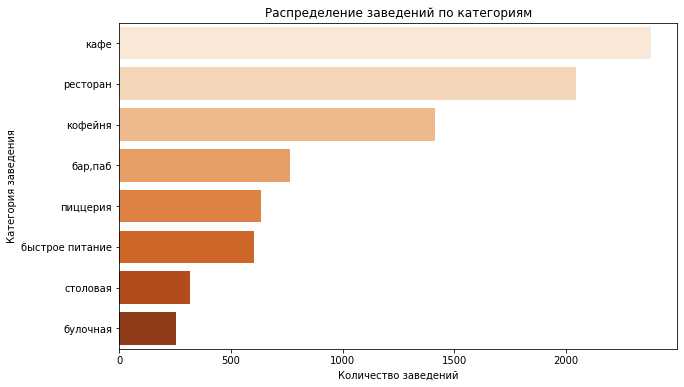

In [20]:
# Строим график распределения заведений по категориям
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='category',
    order=df['category'].value_counts().index,
    palette='Oranges'
)

# Подписываем график
plt.title('Распределение заведений по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('Категория заведения')

# Показываем график
plt.show()

Наиболее распространёнными категориями заведений являются **кафе (2378) и рестораны (2043)**. Также значительную долю занимают **кофейни (1413)**. Остальные категории представлены значительно меньшим количеством заведений. Это показывает, что рынок общественного питания Москвы в основном представлен форматами кафе и ресторанов.

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [21]:
# Проверяем какие административные округа присутствуют в данных
print('Список административных округов в данных:')

district_list = pd.DataFrame({'district': sorted(df['district'].unique())})

# Выводим список округов в виде таблицы
display(district_list)

Список административных округов в данных:


,district
0,Восточный административный округ
1,Западный административный округ
2,Северный административный округ
3,Северо-Восточный административный округ
4,Северо-Западный административный округ
5,Центральный административный округ
6,Юго-Восточный административный округ
7,Юго-Западный административный округ
8,Южный административный округ


In [22]:
# Считаем количество заведений по административным округам
print('Количество заведений по административным округам:')

district_counts = df['district'].value_counts().reset_index()
district_counts.columns = ['district', 'count']

# Выводим результат в виде таблицы
display(district_counts)

Количество заведений по административным округам:


,district,count
0,Центральный административный округ,2242
1,Северный административный округ,900
2,Южный административный округ,892
3,Северо-Восточный административный округ,891
4,Западный административный округ,851
5,Восточный административный округ,798
6,Юго-Восточный административный округ,714
7,Юго-Западный административный округ,709
8,Северо-Западный административный округ,409


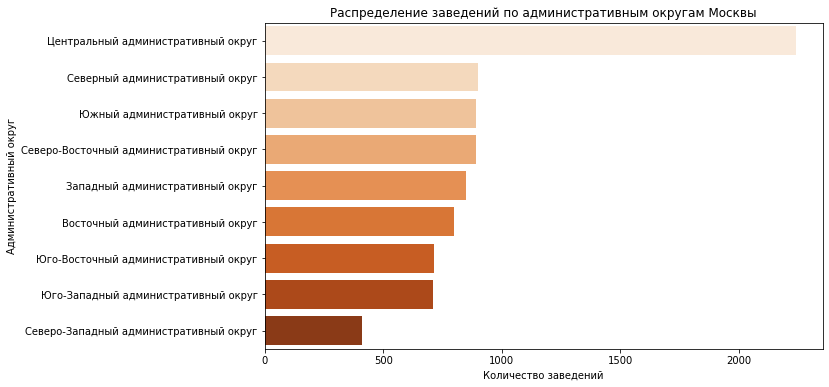

In [23]:
# Строим график распределения заведений по административным округам
plt.figure(figsize=(10,6))

sns.barplot(
    data=district_counts,
    y='district',
    x='count',
    palette='Oranges'
)

# Подписываем график
plt.title('Распределение заведений по административным округам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Административный округ')

# Показываем график
plt.show()

In [24]:
# Создаём датафрейм только для Центрального административного округа
df_cao = df[df['district'] == 'Центральный административный округ']

# Проверяем размер выборки
print('Количество заведений в Центральном административном округе:')
print(df_cao.shape[0])

Количество заведений в Центральном административном округе:
2242


In [25]:
# Считаем количество заведений каждой категории в ЦАО
print('Распределение заведений по категориям в ЦАО:')

cao_category_counts = df_cao['category'].value_counts().reset_index()
cao_category_counts.columns = ['category', 'count']

# Выводим результат в виде таблицы
display(cao_category_counts)

Распределение заведений по категориям в ЦАО:


,category,count
0,ресторан,670
1,кафе,464
2,кофейня,428
3,"бар,паб",364
4,пиццерия,113
5,быстрое питание,87
6,столовая,66
7,булочная,50


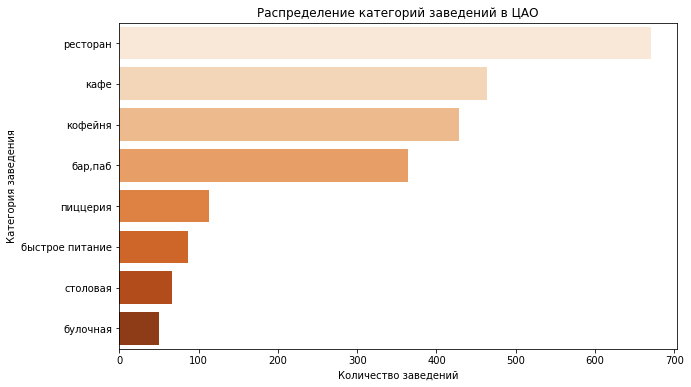

In [26]:
# Строим график распределения категорий заведений в ЦАО
plt.figure(figsize=(10,6))

sns.barplot(
    data=cao_category_counts,
    y='category',
    x='count',
    palette='Oranges'
)

# Подписываем график
plt.title('Распределение категорий заведений в ЦАО')
plt.xlabel('Количество заведений')
plt.ylabel('Категория заведения')

# Показываем график
plt.show()

В данных представлены все основные административные округа Москвы. Анализ распределения показывает, что наибольшее количество заведений общественного питания сосредоточено в **Центральном административном округе — 2242 объекта**, что значительно превышает показатели остальных округов.

В остальных округах количество заведений распределено относительно равномерно и составляет примерно **от 700 до 900 объектов**, тогда как **Северо-Западный административный округ** имеет наименьшее число заведений — **409**.

Отдельный анализ Центрального административного округа показывает, что наиболее распространёнными категориями заведений являются **рестораны (670), кафе (464) и кофейни (428)**. Также значительную долю составляют **бары и пабы (364)**. Менее представлены **пиццерии, заведения быстрого питания, столовые и булочные**.

Полученные результаты подтверждают, что **Центральный округ является основным центром концентрации заведений общественного питания**, что связано с высокой плотностью населения, развитой туристической инфраструктурой, большим количеством офисов и высокой проходимостью.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [27]:
# Считаем количество сетевых и несетевых заведений
print('Соотношение сетевых и несетевых заведений:')

chain_counts = df['chain'].value_counts().reset_index()
chain_counts.columns = ['chain', 'count']

# Выводим результат в виде таблицы
display(chain_counts)

Соотношение сетевых и несетевых заведений:


,chain,count
0,0,5201
1,1,3205


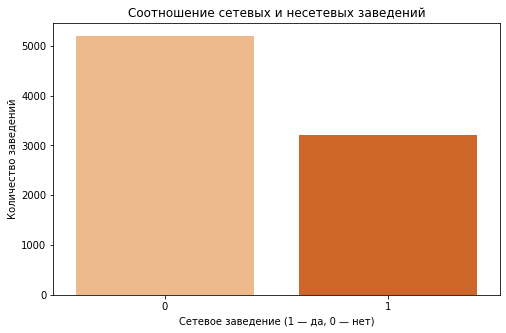

In [28]:
# Строим график соотношения сетевых и несетевых заведений
plt.figure(figsize=(8,5))

sns.barplot(
    data=chain_counts,
    x='chain',
    y='count',
    palette='Oranges'
)

# Подписываем график
plt.title('Соотношение сетевых и несетевых заведений')
plt.xlabel('Сетевое заведение (1 — да, 0 — нет)')
plt.ylabel('Количество заведений')

# Показываем график
plt.show()

In [29]:
# Считаем количество сетевых заведений по категориям
print('Количество сетевых заведений по категориям:')

chain_by_category = (
    df[df['chain'] == 1]['category']
    .value_counts()
    .reset_index()
)

chain_by_category.columns = ['category', 'count']

# Выводим таблицу
display(chain_by_category)

Количество сетевых заведений по категориям:


,category,count
0,кафе,779
1,ресторан,730
2,кофейня,720
3,пиццерия,330
4,быстрое питание,232
5,"бар,паб",169
6,булочная,157
7,столовая,88


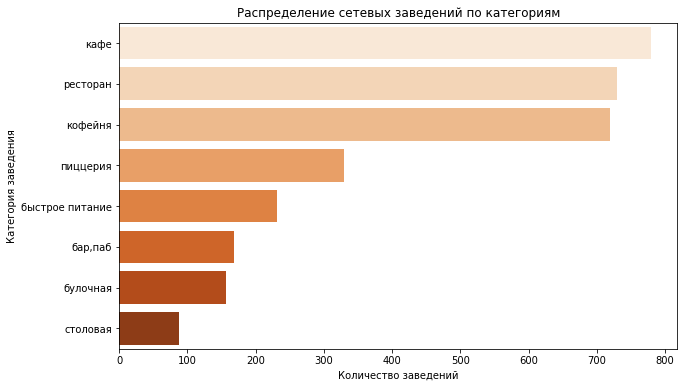

In [30]:
# Строим график распределения сетевых заведений по категориям
plt.figure(figsize=(10,6))

sns.barplot(
    data=chain_by_category,
    y='category',
    x='count',
    palette='Oranges'
)

# Подписываем график
plt.title('Распределение сетевых заведений по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('Категория заведения')

# Показываем график
plt.show()

In [31]:
# Считаем долю сетевых заведений по категориям
category_chain_share = (
    df.groupby('category')['chain']
    .mean()
    .reset_index()
)

category_chain_share.columns = ['category', 'chain_share']

# Сортируем по доле
category_chain_share = category_chain_share.sort_values(
    by='chain_share',
    ascending=False
)

# Выводим таблицу
display(category_chain_share)

,category,chain_share
1,булочная,0.613281
5,пиццерия,0.521327
4,кофейня,0.509554
2,быстрое питание,0.384743
6,ресторан,0.357318
3,кафе,0.327586
7,столовая,0.279365
0,"бар,паб",0.220915


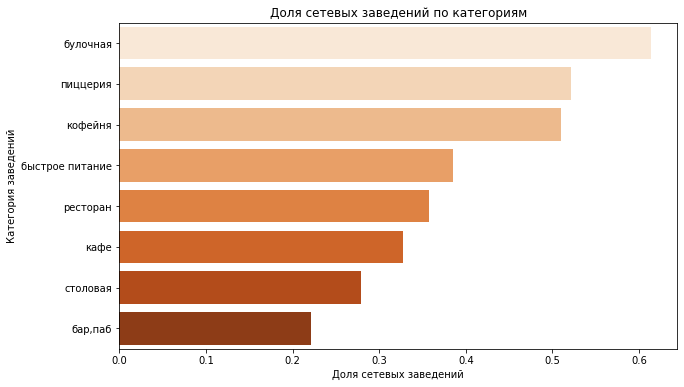

In [32]:
# Строим график доли сетевых заведений по категориям
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_chain_share,
    y='category',
    x='chain_share',
    palette='Oranges'
)

# Подписываем график
plt.title('Доля сетевых заведений по категориям')
plt.xlabel('Доля сетевых заведений')
plt.ylabel('Категория заведений')

plt.show()

Анализ показал, что в рассматриваемых данных несетевых заведений больше, чем сетевых: около 5201 несетевое заведение против 3205 сетевых.

При анализе количества сетевых заведений по категориям видно, что чаще всего сетевой формат встречается среди кафе (779), ресторанов (730) и кофеен (720). Также заметное количество сетевых заведений наблюдается среди пиццерий и заведений быстрого питания.

Анализ доли сетевых заведений внутри категорий показывает, что наибольшая доля сетевых заведений наблюдается среди булочных (около 61%), пиццерий (около 52%) и кофеен (около 51%). Это указывает на то, что данные форматы чаще развиваются именно как сеть.

Наименьшая доля сетевых заведений наблюдается среди баров и пабов, где преобладают независимые заведения.

Таким образом, можно сделать вывод, что сетевой формат наиболее характерен для заведений с относительно стандартизированным меню и форматом обслуживания, тогда как такие категории, как бары и пабы, чаще представлены отдельными независимыми заведениями.

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [33]:
# Изучаем основные статистики по количеству посадочных мест
print('Статистика количества посадочных мест:')

seats_stats = df['seats'].describe()

# Выводим результат
display(seats_stats)

Статистика количества посадочных мест:


count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

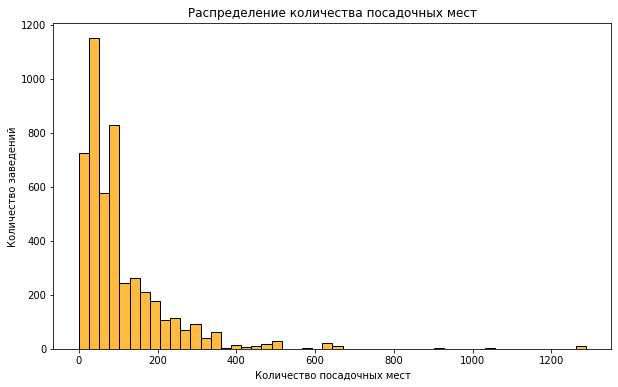

In [34]:
# Строим гистограмму распределения количества посадочных мест
plt.figure(figsize=(10,6))

sns.histplot(
    df['seats'],
    bins=50,
    color='orange'
)

# Подписываем график
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Количество заведений')

plt.show()

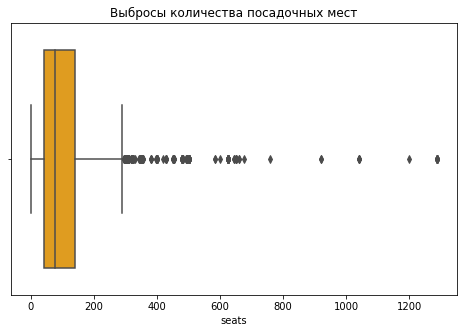

In [35]:
# Строим boxplot для поиска выбросов
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['seats'],
    color='orange'
)

# Подписываем график
plt.title('Выбросы количества посадочных мест')

plt.show()

In [36]:
# Считаем типичное количество посадочных мест по категориям (медиана)
print('Типичное количество посадочных мест по категориям:')

seats_by_category = (
    df.groupby('category')['seats']
    .median()
    .reset_index()
)

seats_by_category.columns = ['category', 'median_seats']

# Сортируем
seats_by_category = seats_by_category.sort_values(
    by='median_seats',
    ascending=False
)

display(seats_by_category)

Типичное количество посадочных мест по категориям:


,category,median_seats
6,ресторан,86.0
0,"бар,паб",82.5
4,кофейня,80.0
7,столовая,75.5
2,быстрое питание,65.0
3,кафе,60.0
5,пиццерия,55.0
1,булочная,50.0


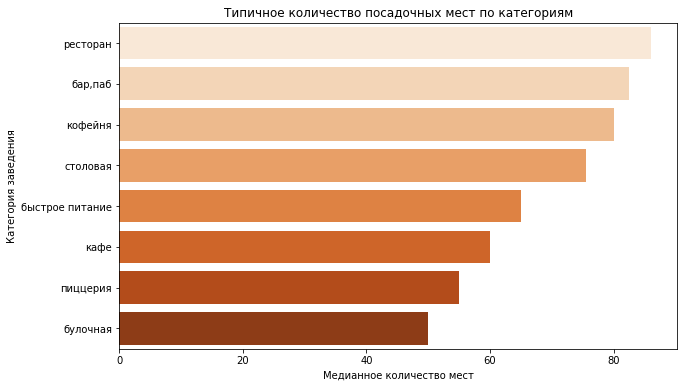

In [37]:
# Строим график типичного количества посадочных мест
plt.figure(figsize=(10,6))

sns.barplot(
    data=seats_by_category,
    y='category',
    x='median_seats',
    palette='Oranges'
)

# Подписываем график
plt.title('Типичное количество посадочных мест по категориям')
plt.xlabel('Медианное количество мест')
plt.ylabel('Категория заведения')

plt.show()

Анализ показал, что большинство заведений имеют от 40 до 140 посадочных мест, медианное значение составляет около 75 мест. Распределение сильно смещено вправо: присутствуют выбросы с очень большим количеством мест (до 1288), что, вероятно, связано с крупными ресторанами, столовыми или фуд-кортами. Также встречаются значения 0 мест, что может означать заведения без посадочных мест или ошибки в данных.

Типичное количество посадочных мест зависит от категории заведения. Больше всего мест обычно имеют рестораны, бары/пабы и кофейни (около 80–86 мест), тогда как пиццерии, кафе и булочные чаще имеют меньшее количество посадочных мест (примерно 50–60).

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [38]:
# Изучаем основные статистики рейтинга заведений
print('Статистика рейтинга заведений:')

rating_stats = df['rating'].describe()

# Выводим результат
display(rating_stats)

Статистика рейтинга заведений:


count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [39]:
# Считаем средний рейтинг по категориям заведений
print('Средний рейтинг по категориям заведений:')

rating_by_category = (
    df.groupby('category')['rating']
    .mean()
    .reset_index()
)

rating_by_category.columns = ['category', 'avg_rating']

# Сортируем для удобства
rating_by_category = rating_by_category.sort_values(
    by='avg_rating',
    ascending=False
)

display(rating_by_category)

Средний рейтинг по категориям заведений:


,category,avg_rating
0,"бар,паб",4.387712
5,пиццерия,4.301264
6,ресторан,4.290357
4,кофейня,4.277282
1,булочная,4.268359
7,столовая,4.211429
3,кафе,4.123886
2,быстрое питание,4.050249


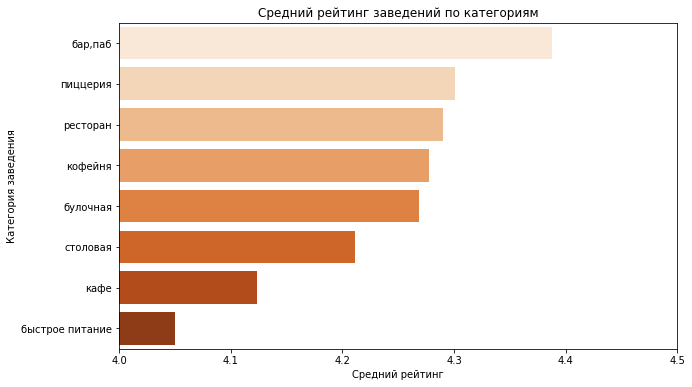

In [40]:
# Строим график распределения среднего рейтинга по категориям
plt.figure(figsize=(10,6))

sns.barplot(
    data=rating_by_category,
    y='category',
    x='avg_rating',
    palette='Oranges'
)

# ограничиваем ось X
plt.xlim(4, 4.5) 

# Подписываем график
plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория заведения')

plt.show()

Средний рейтинг заведений составляет 4.23, при этом большинство значений находится в диапазоне 4.1–4.4, что говорит о достаточно высоких оценках пользователей.

Средние рейтинги по категориям отличаются незначительно. Самые высокие оценки имеют бары/пабы и пиццерии, а немного ниже — кафе и заведения быстрого питания. Однако разница между категориями небольшая.

Таким образом, можно сделать вывод, что тип заведения практически не влияет на средний рейтинг, и в целом все категории общепита получают схожие оценки посетителей.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [41]:
# Подготавливаем данные для анализа корреляции

df_corr = df.copy()

# Кодируем категориальные признаки
df_corr['category_code'] = df_corr['category'].astype('category').cat.codes
df_corr['district_code'] = df_corr['district'].astype('category').cat.codes

# Проверяем сетевые заведения (0 / 1)
df_corr['chain'] = df_corr['chain'].astype(int)

# Круглосуточные заведения (0 / 1)
df_corr['is_24_7'] = df_corr['is_24_7'].astype(int)

# Ценовую категорию тоже переводим в числовой код
df_corr['price_code'] = df_corr['price'].astype('category').cat.codes

In [42]:
# Считаем корреляцию рейтинга с другими признаками
print('Корреляция рейтинга с другими признаками:')

corr_table = df_corr[
    ['rating','category_code','district_code','chain','seats','price_code','is_24_7']
].corr()

display(corr_table[['rating']].sort_values(by='rating', ascending=False))

Корреляция рейтинга с другими признаками:


,rating
rating,1.000000
price_code,0.121419
category_code,0.030626
district_code,0.022671
seats,0.021025
chain,-0.014954
is_24_7,-0.103315


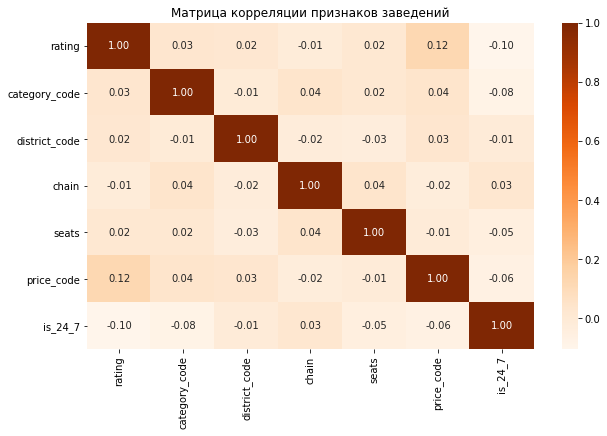

In [43]:
# Строим матрицу корреляции
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_table,
    annot=True,
    cmap='Oranges',
    fmt='.2f'
)

plt.title('Матрица корреляции признаков заведений')

plt.show()

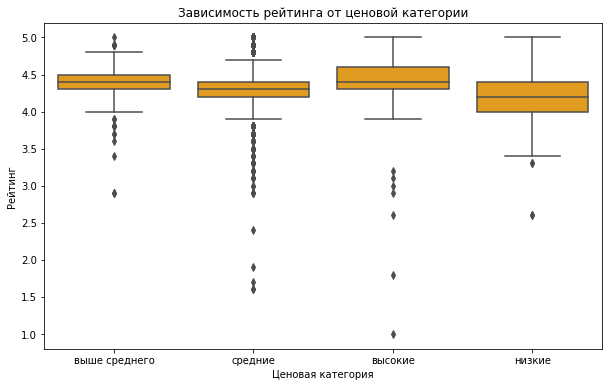

In [44]:
# Проверяем связь рейтинга и ценовой категории

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='price',
    y='rating',
    color='orange'
)

plt.title('Зависимость рейтинга от ценовой категории')
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')

plt.show()

Матрица корреляции показала, что самая заметная связь рейтинга наблюдается с ценовой категорией, однако коэффициент корреляции составляет всего 0.12, что говорит о очень слабой зависимости.

Диаграмма размаха подтверждает этот результат: рейтинги заведений во всех ценовых категориях находятся примерно в одном диапазоне — около 4.1–4.5. Более дорогие заведения иногда имеют немного более высокий медианный рейтинг, однако различия между категориями небольшие.

Таким образом, можно сделать вывод, что ценовая категория оказывает лишь слабое влияние на рейтинг, и в целом оценки пользователей примерно одинаковы для заведений разных ценовых уровней.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [45]:
# Группируем данные по названию заведений и считаем количество точек сети
print('Топ-15 самых популярных сетей по количеству заведений:')

top_chains = (
    df.groupby('name')
    .agg(
        count_places=('name', 'count'),
        avg_rating=('rating', 'mean'),
        category=('category', lambda x: x.mode()[0])
    )
    .reset_index()
)

# Сортируем по количеству заведений
top_chains = top_chains.sort_values(
    by='count_places',
    ascending=False
).head(15)

display(top_chains)

Топ-15 самых популярных сетей по количеству заведений:


,name,count_places,avg_rating,category
2825,кафе,189,3.880952,кафе
5418,шоколадница,120,4.177500,кофейня
2532,домино'с пицца,77,4.171429,пиццерия
2500,додо пицца,74,4.286486,пиццерия
1137,one price coffee,72,4.069444,кофейня
5491,яндекс лавка,69,3.872464,ресторан
413,cofix,65,4.075385,кофейня
1263,prime,50,4.116000,ресторан
4993,хинкальная,44,4.322727,кафе
5319,шаурма,43,3.909302,быстрое питание


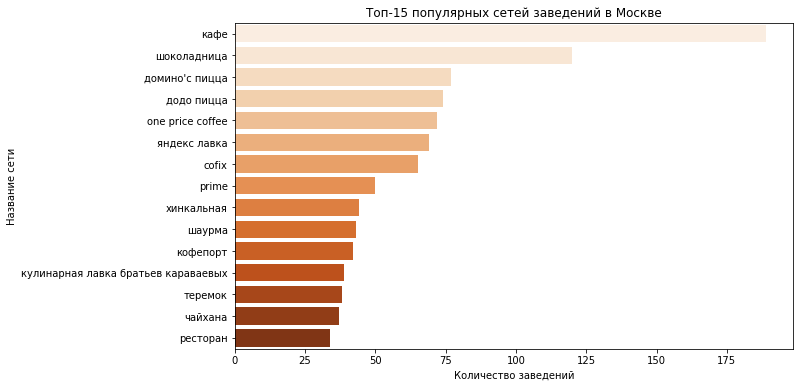

In [46]:
# Строим график популярности сетей
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_chains,
    y='name',
    x='count_places',
    palette='Oranges'
)

plt.title('Топ-15 популярных сетей заведений в Москве')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')

plt.show()

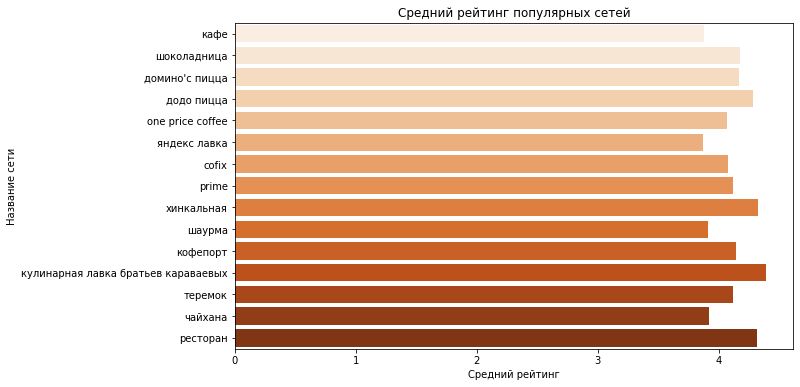

In [47]:
# График среднего рейтинга популярных сетей
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_chains,
    y='name',
    x='avg_rating',
    palette='Oranges'
)

plt.title('Средний рейтинг популярных сетей')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')

plt.show()

Анализ показал, что наиболее распространённые сети общественного питания в Москве — это кофейни, пиццерии и кафе. Самое большое количество заведений имеет сеть «Кафе» (189 точек), далее следуют «Шоколадница» (120), «Доминос пицца» (77) и «Додо пицца» (74).

Средний рейтинг у популярных сетей находится примерно в диапазоне 3.8–4.4, что говорит о достаточно стабильном уровне оценок.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [48]:
# Изучаем статистику среднего чека
print('Статистика среднего чека:')

bill_stats = df['middle_avg_bill'].describe()

display(bill_stats)

Статистика среднего чека:


count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

In [49]:
# Считаем средний чек по округам Москвы
print('Средний чек по административным округам:')

avg_bill_by_district = (
    df.groupby('district')['middle_avg_bill']
    .mean()
    .reset_index()
)

avg_bill_by_district.columns = ['district', 'avg_bill']

# сортируем по среднему чеку
avg_bill_by_district = avg_bill_by_district.sort_values(
    by='avg_bill',
    ascending=False
)

display(avg_bill_by_district)

Средний чек по административным округам:


,district,avg_bill
5,Центральный административный округ,1191.057547
1,Западный административный округ,1053.225490
2,Северный административный округ,927.959627
8,Южный административный округ,834.398089
4,Северо-Западный административный округ,822.222930
0,Восточный административный округ,820.626923
7,Юго-Западный административный округ,792.561702
3,Северо-Восточный административный округ,716.611296
6,Юго-Восточный административный округ,654.097938


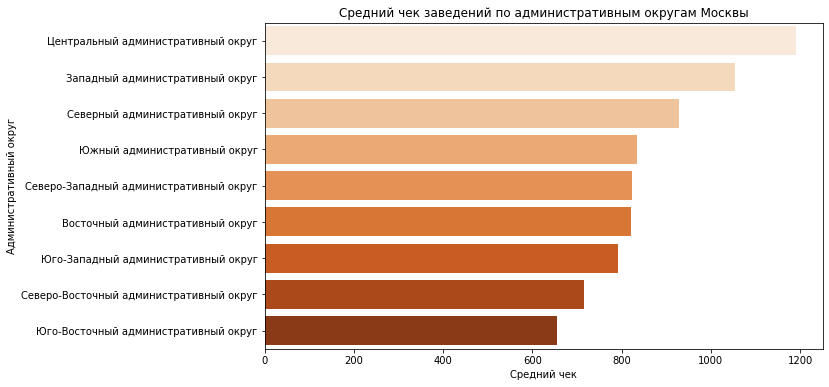

In [50]:
# График среднего чека по округам
plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_bill_by_district,
    y='district',
    x='avg_bill',
    palette='Oranges'
)

plt.title('Средний чек заведений по административным округам Москвы')
plt.xlabel('Средний чек')
plt.ylabel('Административный округ')

plt.show()

---


In [51]:
# Создаем признак: центр / не центр
df['is_center'] = df['district'] == 'Центральный административный округ'

# считаем средний чек
center_bill = (
    df.groupby('is_center')['middle_avg_bill']
    .mean()
    .reset_index()
)

center_bill['is_center'] = center_bill['is_center'].map({
    True:'ЦАО',
    False:'Другие округа'
})

display(center_bill)

,is_center,middle_avg_bill
0,Другие округа,839.822882
1,ЦАО,1191.057547


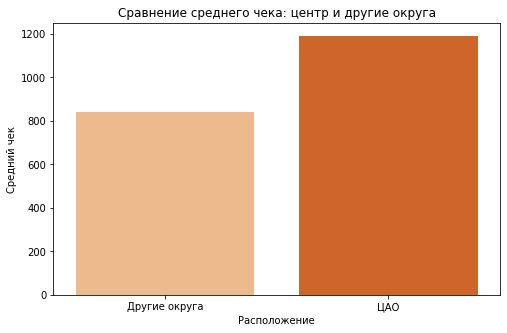

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=center_bill,
    x='is_center',
    y='middle_avg_bill',
    palette='Oranges'
)

plt.title('Сравнение среднего чека: центр и другие округа')
plt.xlabel('Расположение')
plt.ylabel('Средний чек')

plt.show()

Статистика показала, что средний чек по всем заведениям составляет около 958 рублей, при этом медиана равна 750 рублям, что говорит о наличии более дорогих заведений, увеличивающих среднее значение.

Анализ по округам показал заметную разницу в ценах. Самый высокий средний чек наблюдается в Центральном административном округе (ЦАО) — около 1191 рубля. Далее следуют Западный и Северный округа со средними значениями около 1053 и 928 рублей соответственно. Самые низкие средние чеки зафиксированы в Юго-Восточном округе (около 654 рублей) и Северо-Восточном округе (около 717 рублей).

Дополнительное сравнение центра и остальных округов подтвердило эту закономерность:

- ЦАО — примерно 1191 руб.

- Другие округа — около 840 руб.

Таким образом, можно сделать вывод, что удалённость от центра города влияет на уровень цен в заведениях. Чем ближе заведение расположено к центру Москвы, тем выше средний чек. Это может объясняться более высокой стоимостью аренды, большей концентрацией туристов и деловой активности, а также более высокой платежеспособностью аудитории в центральных районах города.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

В ходе исследовательского анализа были изучены рейтинги заведений, популярность сетей и уровень цен в разных округах Москвы.

Анализ корреляции показал, что сильной связи между рейтингом и характеристиками заведений не наблюдается. Наиболее заметная, но всё же слабая зависимость обнаружена между рейтингом и ценовой категорией.

Среди самых популярных сетей преобладают кафе, кофейни и пиццерии, такие как «Шоколадница», «Додо Пицца», «Доминос Пицца», Cofix и One Price Coffee. Их средний рейтинг в основном находится на уровне около 4 баллов.

Анализ среднего чека показал, что самые высокие цены наблюдаются в Центральном административном округе, тогда как в других округах средний чек ниже. Это говорит о том, что чем ближе заведение к центру города, тем выше уровень цен.

## Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

**1. Общий обзор проделанной работы**

В ходе исследования были проанализированы данные о заведениях общественного питания Москвы. Были изучены характеристики заведений, их рейтинги, популярность сетей и уровень среднего чека в разных административных округах. Также была проверена связь рейтингов с различными параметрами заведений и проведён анализ ценовой политики в зависимости от расположения.

**2. Главные выводы**

Анализ показал, что сильной зависимости между рейтингом заведений и их характеристиками не наблюдается. Наиболее заметная, но всё же слабая связь выявлена между рейтингом и ценовой категорией.

Среди наиболее популярных сетей преобладают кафе, кофейни и пиццерии. Крупные сети представлены большим количеством точек и имеют стабильно высокий средний рейтинг около 4 баллов, что говорит о хорошем уровне качества.

Также было выявлено, что расположение заведения влияет на уровень цен. В Центральном административном округе средний чек заметно выше, чем в других округах Москвы, что связано с более высокой стоимостью аренды и большей концентрацией клиентов.

**3. Рекомендации**

На основе анализа можно рекомендовать открывать новые заведения в формате кафе или кофейни, так как этот формат наиболее распространён и востребован на рынке.

Если целью является высокий средний чек, стоит рассматривать локации ближе к центру города. Если же задача — привлечь более широкий поток клиентов, можно рассмотреть районы вне центра, где цены ниже и конкуренция может быть менее высокой.

Также важно уделять внимание качеству обслуживания и клиентскому опыту, так как именно эти факторы, вероятно, оказывают большее влияние на рейтинг заведений, чем их формальные характеристики.